# Exploratory Analysis: Daily Orders Time Series

An exploratory pass over a synthetic daily-orders dataset. The goal is to establish the structural properties of the series that downstream modelling decisions depend on.

**What this notebook covers**

1. Visualise the raw series for obvious trend, seasonality, or anomalies.
2. Decompose into trend / seasonal / residual at weekly and yearly periods.
3. Test for stationarity with the Augmented Dickey-Fuller test on raw and differenced series.
4. Define reusable splits, a single holdout and a walk-forward generator.
5. Profile demand by day of the week and translate it into an operational implication.

## 1. Load the data

The dataset is a synthetic daily order log. Setting the date column as the index makes downstream plotting, slicing, and resampling behave correctly.

In [1]:
import pandas as pd

df = pd.read_csv("../files/synthetic_orders.csv", parse_dates=["date"])
df = df.set_index("date")
df.head()

,orders_total,orders_dc1,orders_dc2,is_promo,day_of_week,month
date,,,,,,
2024-01-01,3701,2039,1662,0,Monday,1
2024-01-02,3596,2267,1329,0,Tuesday,1
2024-01-03,3340,1784,1556,0,Wednesday,1
2024-01-04,3406,2130,1276,0,Thursday,1
2024-01-05,3120,1963,1157,0,Friday,1


## 2. Visualise the raw series

A single line plot is the cheapest, highest-signal first look at any time series: it shows trend, level shifts, seasonal swings, gaps, or outliers at a glance — before reaching for any test or model.

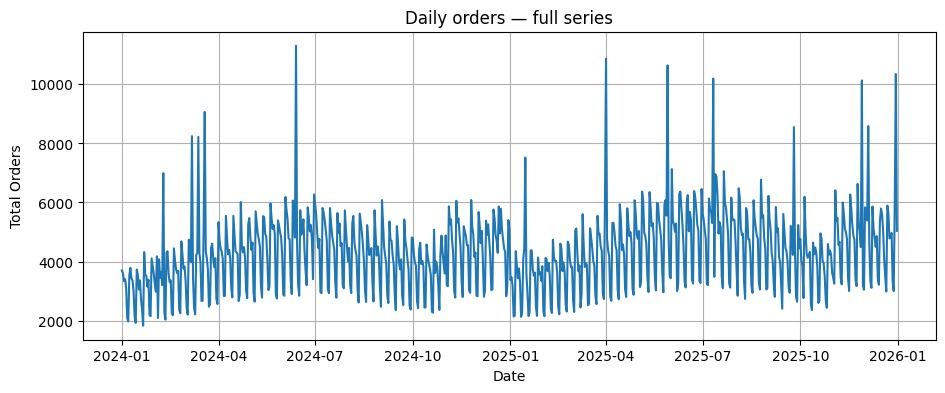

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(11, 4))
plt.plot(df.index, df["orders_total"])
plt.grid(True)
plt.xlabel("Date")
plt.ylabel("Total Orders")
plt.title("Daily orders — full series")
plt.savefig("../figures/01_full_series.png", bbox_inches="tight")
plt.show()

## 3. Seasonal decomposition: weekly period

`statsmodels.tsa.seasonal.seasonal_decompose` separates the series into observed / trend / seasonal / residual using a centered moving average. With `period=7` it isolates the **weekly cycle** explicitly.

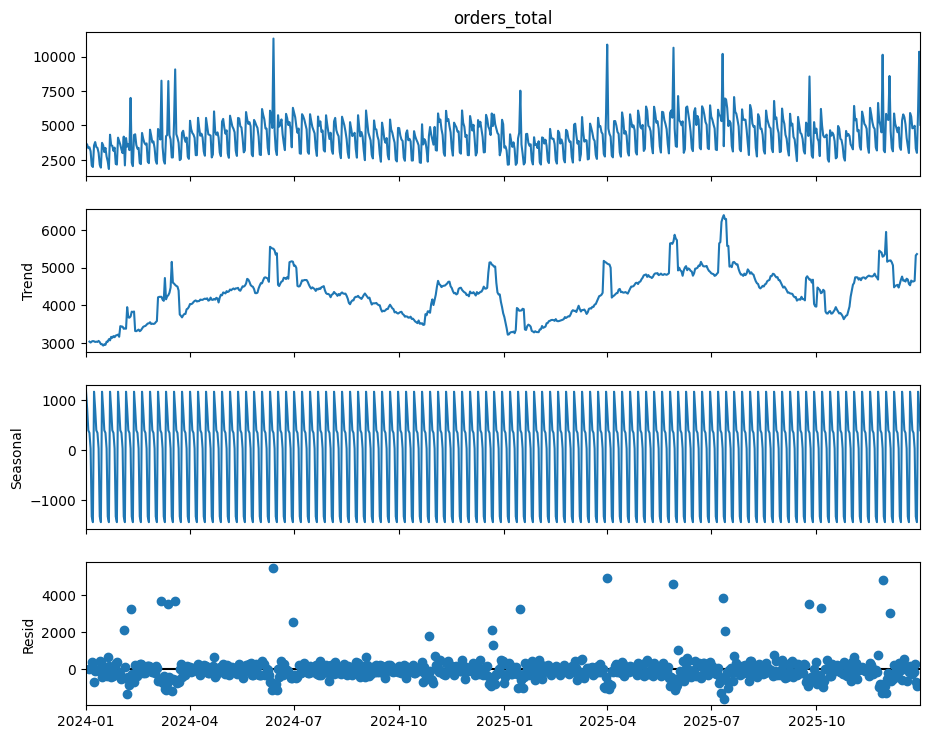

In [3]:
from statsmodels.tsa.seasonal import seasonal_decompose

result_weekly = seasonal_decompose(df["orders_total"], period=7)
fig = result_weekly.plot()
fig.set_size_inches(10, 8)
plt.show()

**Reading the four panels**

- **Observed**: The raw `orders_total` series. The other three panels add up (additive model, the default) to reproduce it; it serves as a sanity check that the input looks right.
- **Trend**: The slow-moving level, estimated with a centered 7-day moving average. It strips the weekly cycle and day-to-day noise, leaving the underlying direction. 
- **Seasonal**: The repeating weekly pattern (period 7). Each weekday gets a fixed offset stating how much above/below the trend that day typically sits. A clear, regular shape means weekday-of-week is a real driver of orders.
- **Residual**: What is left after subtracting trend and seasonal from observed (`resid = observed − trend − seasonal`). Structureless noise around zero means the trend + weekly-seasonal model captures the series well.

## 4. Seasonal decomposition i.e yearly period

Repeating the decomposition with `period=365` surfaces the **annual cycle** instead of the weekly one. Comparing the two seasonal panels is informative: the weekly pattern is a small, fast oscillation, while the yearly pattern carries large Q4 spikes consistent with end-of-year promotional and holiday demand.

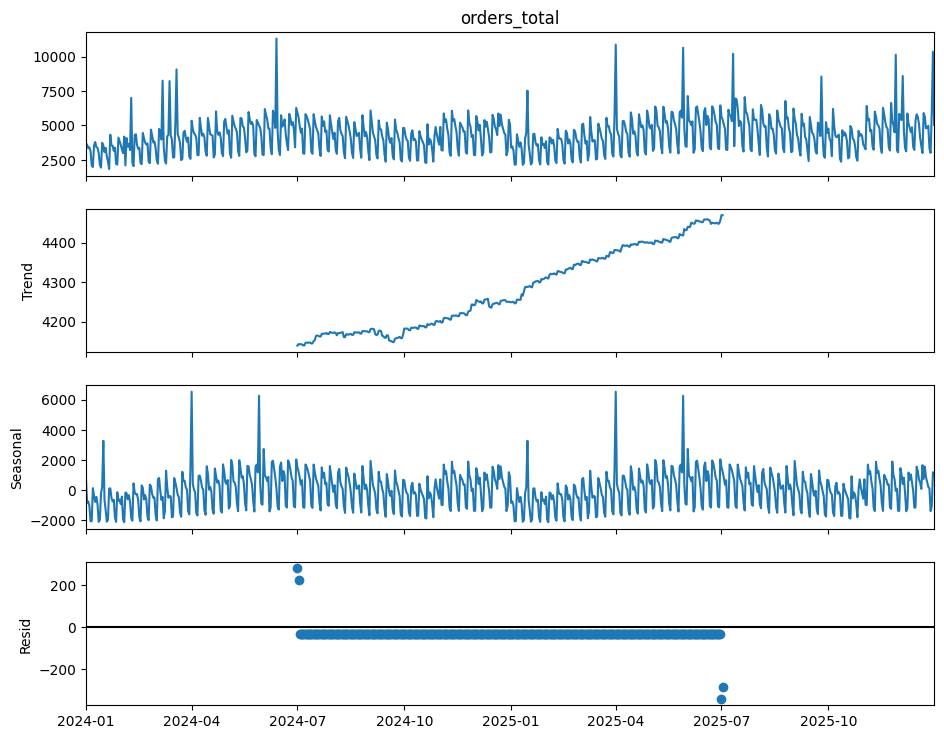

In [4]:
result_yearly = seasonal_decompose(df["orders_total"], period=365)
fig = result_yearly.plot()
fig.set_size_inches(10, 8)
plt.show()

**Reading the yearly decomposition**

Both weekly and yearly cycles are present, on very different scales:

- The **weekly** seasonal panel from Section 3 is a tight, regular Mon to Sun wave with small amplitude relative to total volume.
- The **yearly** seasonal panel here is a long, smooth wave with pronounced spikes in Q4, consistent with end-of-year promotional and holiday demand.



## 5. Stationarity check: Augmented Dickey Fuller test

In [5]:
from statsmodels.tsa.stattools import adfuller

raw = adfuller(df["orders_total"].values)
print(f"Raw series:   ADF = {raw[0]:.3f}  p = {raw[1]:.4f}  critical = {raw[4]}")

Raw series:   ADF = -2.875  p = 0.0484  critical = {'1%': np.float64(-3.439593802573824), '5%': np.float64(-2.865619356068967), '10%': np.float64(-2.568942332870462)}


In [6]:
diffed = adfuller(df["orders_total"].diff().dropna().values)
print(f"Differenced:  ADF = {diffed[0]:.3f}  p = {diffed[1]:.4f}  critical = {diffed[4]}")

Differenced:  ADF = -9.439  p = 0.0000  critical = {'1%': np.float64(-3.439606888036868), '5%': np.float64(-2.865625121924057), '10%': np.float64(-2.5689454046801052)}


**Interpretation**

After first-differencing, the ADF statistic drops from about −2.9 to −9.4, well below all critical values and the p-value falls from 0.048 to essentially zero. These together strongly reject the null hypothesis: the differenced series is stationary.

## 6. Reusable splits: Holdout and walk-forward

Two utilities for evaluating any forecasting model on this dataset:

- `time_series_split` A single chronological holdout (last `n_test` rows). Cheap, but its accuracy estimate depends on one specific window.
- `walk_forward_split` - Yields `n_splits` train/test pairs where the training window grows by `horizon` days each step. This mirrors how a model would be retrained and redeployed in production and gives a more stable accuracy estimate.

In [7]:
def time_series_split(df, n_test):
    train_df = df.iloc[:-n_test]
    test_df = df.iloc[-n_test:]
    assert test_df.index.min() > train_df.index.max(), "train and test must not overlap in time"
    return train_df, test_df

train_df, test_df = time_series_split(df["orders_total"], 56)
print(f"train: {train_df.index.min().date()} → {train_df.index.max().date()}  ({len(train_df)} days)")
print(f"test:  {test_df.index.min().date()} → {test_df.index.max().date()}  ({len(test_df)} days)")

train: 2024-01-01 → 2025-11-05  (675 days)
test:  2025-11-06 → 2025-12-31  (56 days)


In [8]:
def walk_forward_split(df, n_splits, horizon):
    N = len(df)
    first_train_end = N - n_splits * horizon

    for i in range(n_splits):
        train_end = first_train_end + i * horizon
        test_start = train_end
        test_end = train_end + horizon

        train_df = df.iloc[:train_end]
        test_df = df.iloc[test_start:test_end]

        yield train_df, test_df


In [9]:
for train, test in walk_forward_split(df["orders_total"], n_splits=5, horizon=14):
    print(
        f"train: {train.index.min().date()} ==> {train.index.max().date()}"
        f"      test: {test.index.min().date()} ==> {test.index.max().date()}"
    )

train: 2024-01-01 ==> 2025-10-22      test: 2025-10-23 ==> 2025-11-05
train: 2024-01-01 ==> 2025-11-05      test: 2025-11-06 ==> 2025-11-19
train: 2024-01-01 ==> 2025-11-19      test: 2025-11-20 ==> 2025-12-03
train: 2024-01-01 ==> 2025-12-03      test: 2025-12-04 ==> 2025-12-17
train: 2024-01-01 ==> 2025-12-17      test: 2025-12-18 ==> 2025-12-31


## 7. Day-of-week profile

The decomposition already hinted that weekday matters. This section makes that quantitative, mean and standard deviation per weekday, plus a bar chart with error bars to show the spread.

In [10]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
stats = df.groupby("day_of_week")["orders_total"].agg(["mean", "std"]).loc[weekday_order]
stats

,mean,std
day_of_week,,
Monday,5453.971429,774.274455
Tuesday,5159.180952,1098.979367
Wednesday,4689.676190,789.421471
Thursday,4636.951923,1267.358091
Friday,4328.192308,1029.661798
Saturday,2978.644231,515.730737
Sunday,2868.403846,770.891937


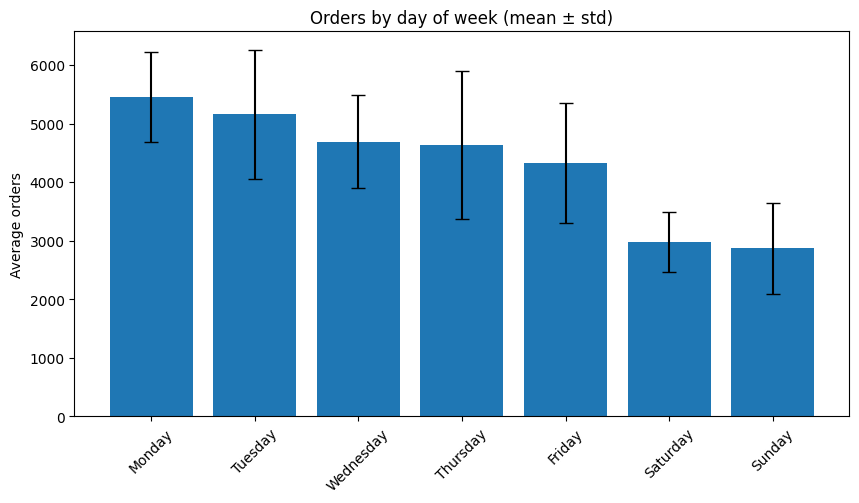

In [11]:
plt.figure(figsize=(10, 5))
plt.bar(stats.index, stats["mean"], yerr=stats["std"], capsize=5)
plt.ylabel("Average orders")
plt.title("Orders by day of week (mean ± std)")
plt.xticks(rotation=45)
plt.show()

In [12]:
heaviest = stats["mean"].idxmax()
lightest = stats["mean"].idxmin()

print(f"Heaviest day: {heaviest}  ({stats.loc[heaviest, 'mean']:.0f} orders avg)")
print(f"Lightest day: {lightest}  ({stats.loc[lightest, 'mean']:.0f} orders avg)")

Heaviest day: Monday  (5454 orders avg)
Lightest day: Sunday  (2868 orders avg)


**Operational implication**

Monday carries the highest average order volume; Sunday the lowest. For staffing, inventory preparation, and delivery capacity, the practical action is to scale up resources on Monday and scale them down on Sunday relative to the weekly mean.